In [1]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL

import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

from collections import defaultdict

import matplotlib as mpl
import matplotlib.pyplot as plt
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,
    "axes.labelsize": 24,
    "legend.fontsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,
    "axes.edgecolor": "black",

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,
    "ytick.minor.width": 2,

    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
}
mpl.rcParams.update(config)

import astropy.units as u
import astropy

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(("./DJAV4.2Catalog.pkl"))

print("="*50)
print(f"Total {(DJAv4Catalog.sample_num())} sample objectss loaded.")
print("="*50)

Total 1102 sample objectss loaded.


Categorizing 1102 objects...
Group 0: 102 objects, Mean BD=0.000
Group 1: 148 objects, Mean BD=0.062
Group 2: 150 objects, Mean BD=0.147
Group 3: 111 objects, Mean BD=0.246
Group 4: 69 objects, Mean BD=0.363
Group 5: 44 objects, Mean BD=0.517
Group 6: 34 objects, Mean BD=0.731

Computing average spectra...
Applied masks to 8 regions.
  Group 0: Processed.
Applied masks to 8 regions.
  Group 1: Processed.
Applied masks to 8 regions.
  Group 2: Processed.
Applied masks to 8 regions.
  Group 3: Processed.
Applied masks to 8 regions.
  Group 4: Processed.
Applied masks to 8 regions.
  Group 5: Processed.
Applied masks to 8 regions.
  Group 6: Processed.
Reference spectrum smoothed.
Computed effective curve and errors using smoothed reference.
Fitting polynomial (Weighted Least Squares) with 988 points...
Polynomial Coefficients errors: [0.00131502 0.01416192 0.04505233 0.04319419]
Polynomial Fit Coefficients (highest power first): [ 0.00518034 -0.15976525  1.40120618 -2.04880455]
Derived P

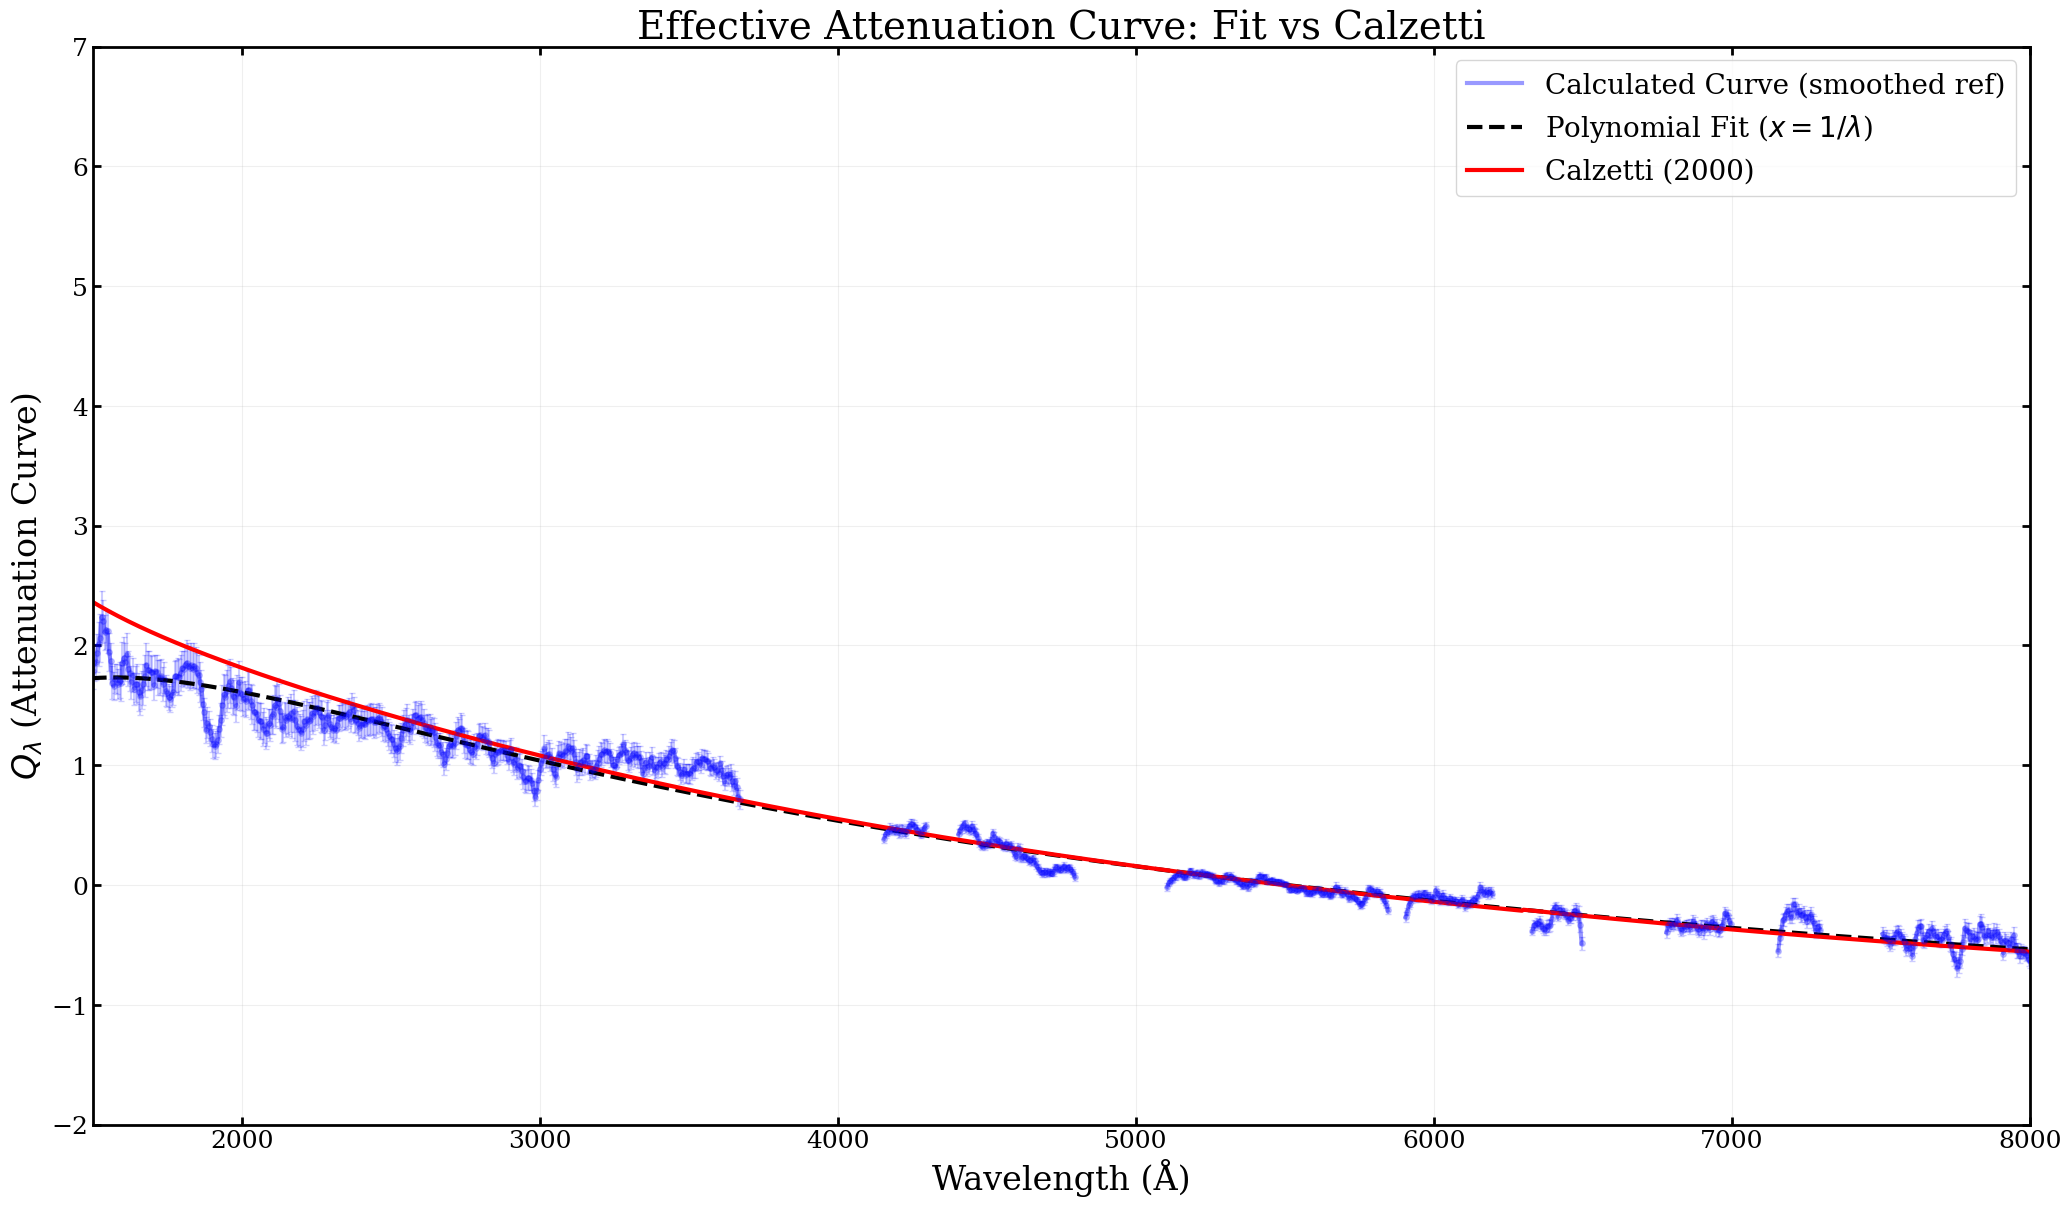

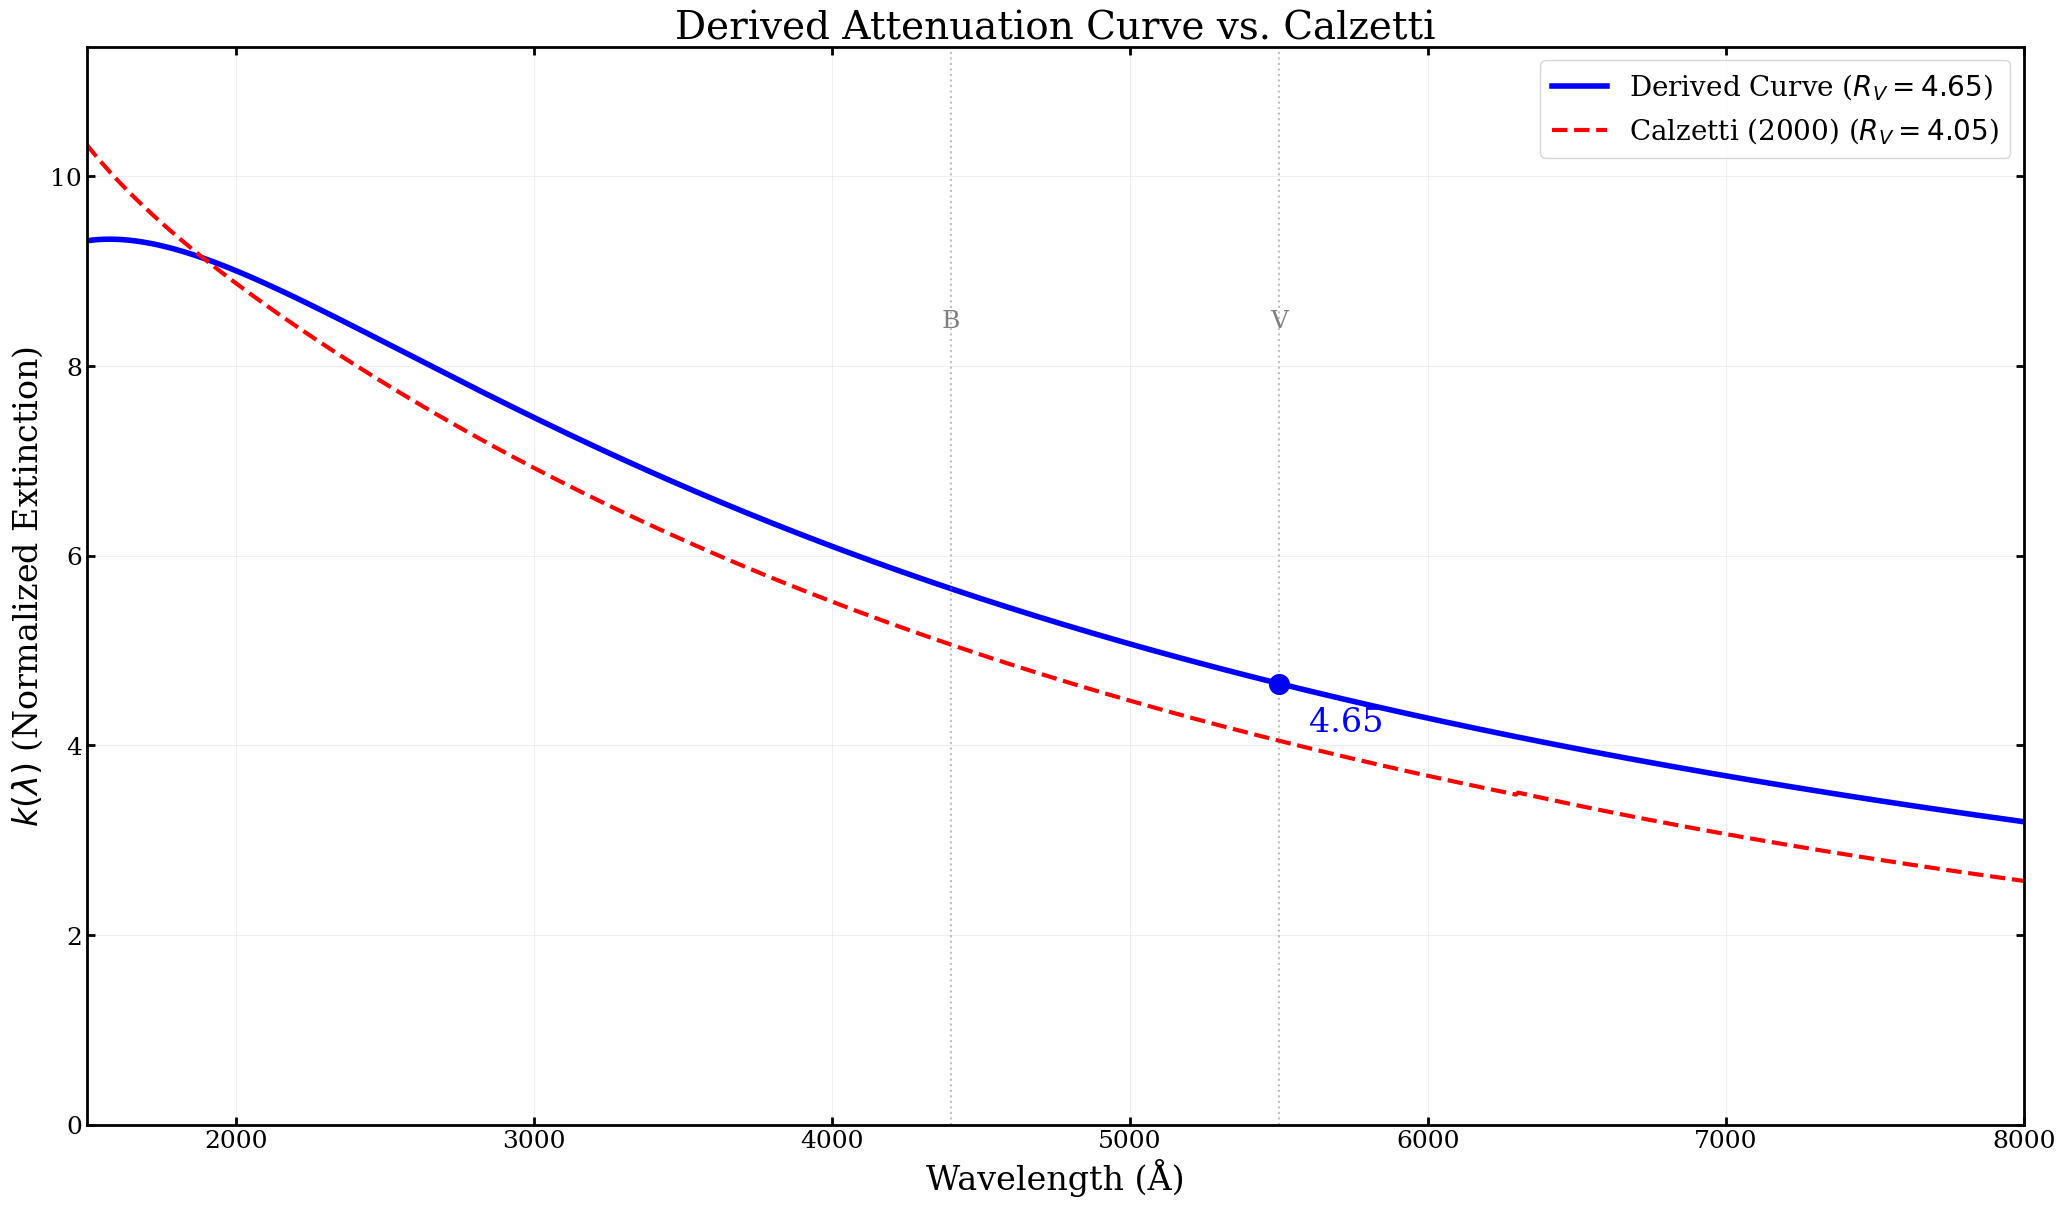

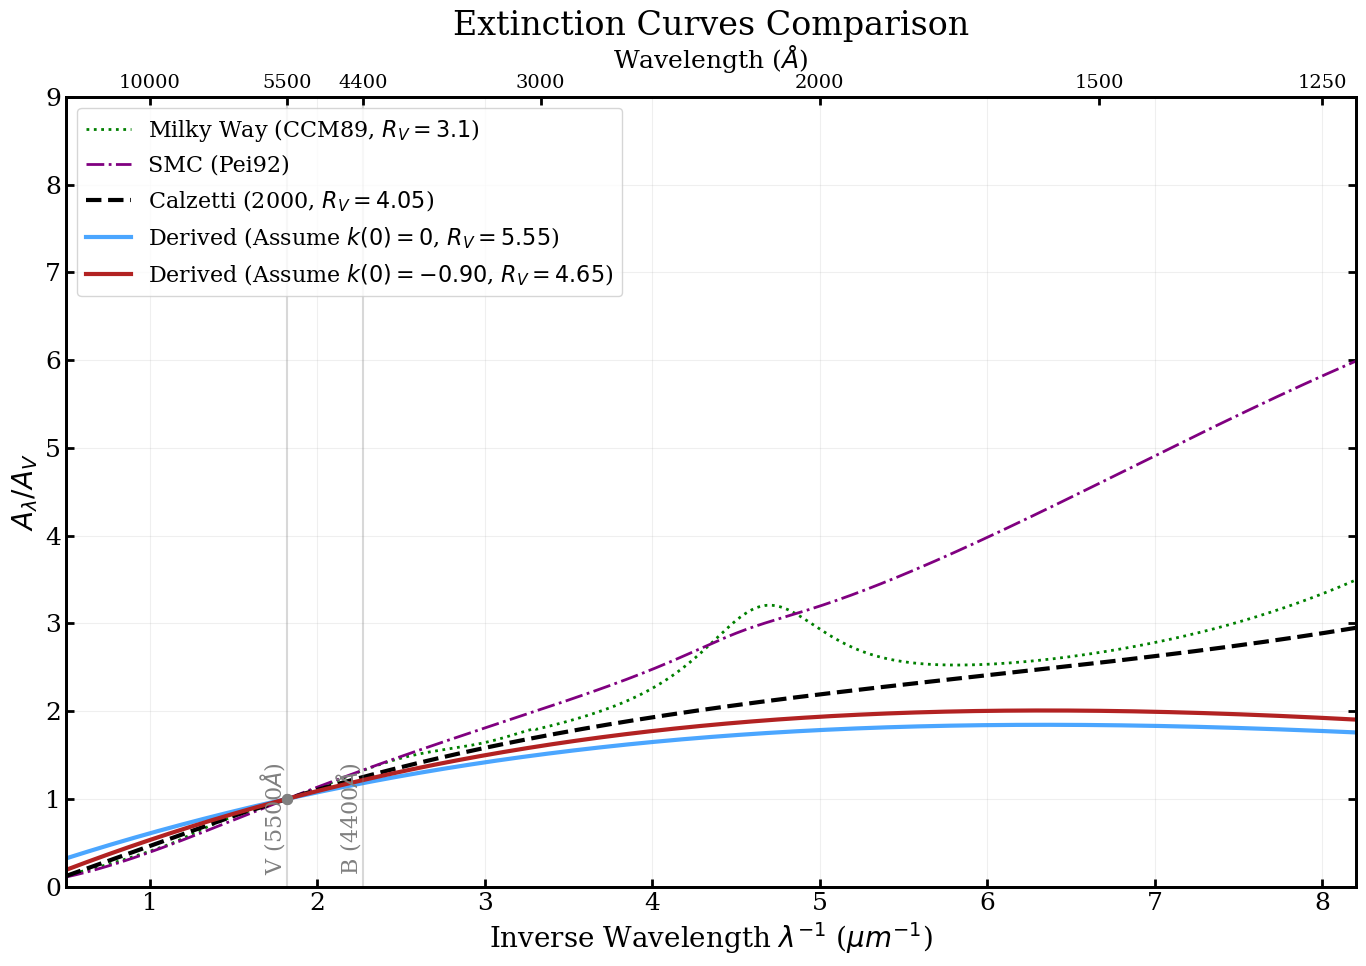

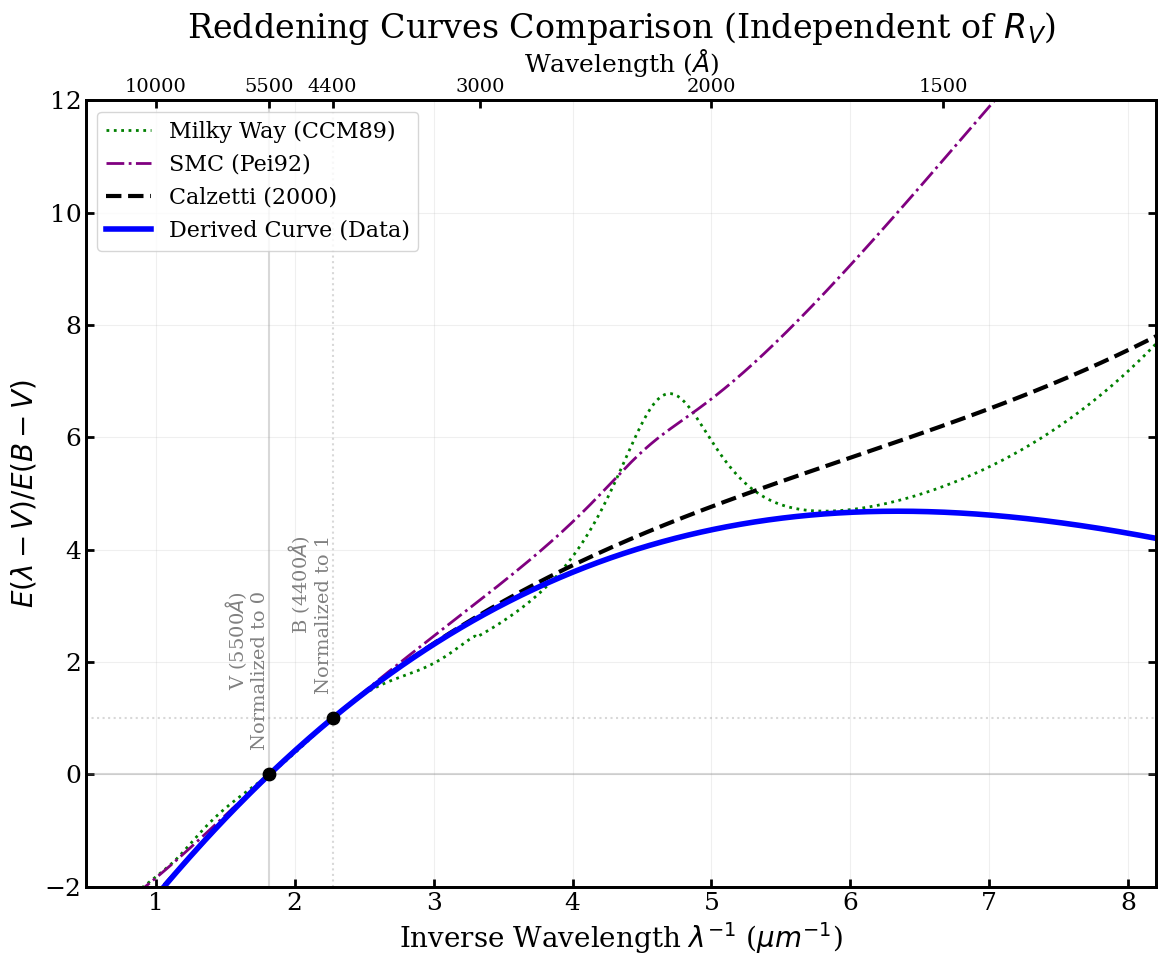

(<Figure size 1200x1000 with 2 Axes>,
 <Axes: title={'center': 'Reddening Curves Comparison (Independent of $R_V$)'}, xlabel='Inverse Wavelength $\\lambda^{-1}$ ($\\mu m^{-1}$)', ylabel='$E(\\lambda - V) / E(B - V)$'>)

In [2]:

analyst = FL.DustAttenuationAnalyst(DJAv4Catalog)

# 2. 准备 ID 列表
target_ids = []
for surveyid_subid, entry in DJAv4Catalog.catalog_iterator():
    if entry.get('sample_flag'):
        target_ids.append(surveyid_subid)

# 3. 数据处理管线
analyst.load_and_group_objects(target_ids)
analyst.compute_average_spectra()

# 4. 计算 Q 曲线 (这里选择使用 'smoothed' 模式)
analyst.compute_attenuation_curves(mode='smoothed')

# 5. 拟合与分析
analyst.fit_polynomial(order=3)
# 假设我们想让无穷远处截距匹配 Calzetti 的推断值 -0.898
analyst.derive_k_curve_parameters(intercept_val=-0.89877)

# 6. 出图
analyst.plot_fit_vs_calzetti()           # 拟合效果
analyst.plot_derived_k_curve()           # 最终 k(lambda) 与 Rv
analyst.plot_extinction_curves_comparison()  # Extinction 曲线对比
analyst.plot_reddening_curve_comparison()# 形状对比